In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

In [5]:
import julia
from julia import Main
Main.eval("using QuadGK")

In [6]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\sigma.jl")

<PyCall.jlwrap integrated>

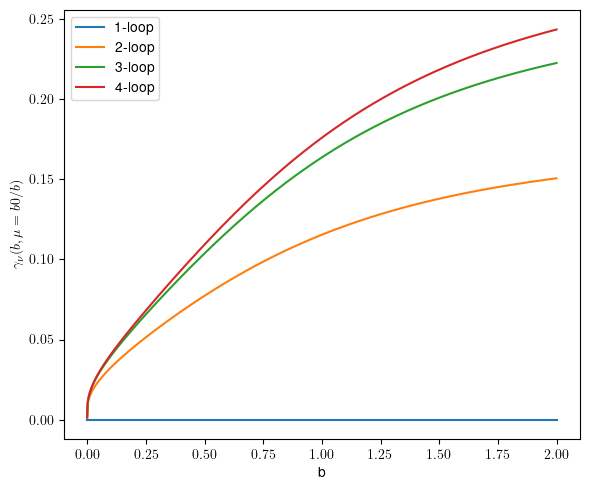

In [6]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-9),2,length)

α_list = np.zeros(length)

for index, bp in enumerate(b_list):
    bstar = bp/(1+(bp/b0)**2)**0.5
    α_list[index] = Main.alpha_s_func(μf=b0/bstar, μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    v_1[index] = 2*Main.γν_raw(αs=α_list[index], order=1, nf=5)
    v_2[index] = 2*Main.γν_raw(αs=α_list[index], order=2, nf=5)
    v_3[index] = 2*Main.γν_raw(αs=α_list[index], order=3, nf=5)
    v_4[index] = 2*Main.γν_raw(αs=α_list[index], order=4, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop")
ax1.plot(b_list, v_2, label="2-loop")
ax1.plot(b_list, v_3, label="3-loop")
ax1.plot(b_list, v_4, label="4-loop")
ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b) $")
ax1.legend()

plt.tight_layout()  
plt.show()

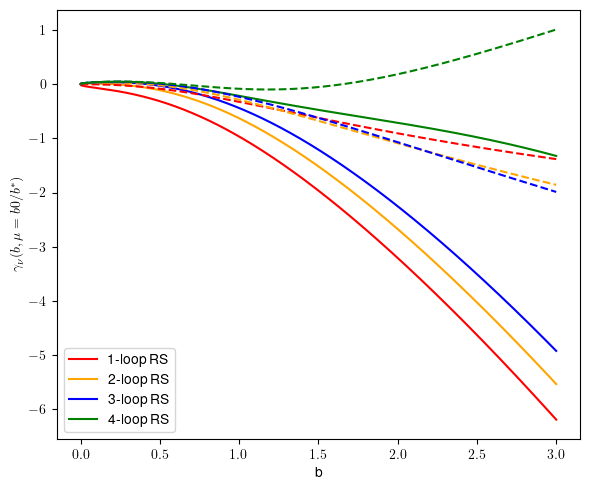

In [10]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-9),3,length)

α_list = np.zeros(length)
bstar_list = np.zeros(length)

for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5
    α_list[index] = Main.alpha_s_func(μf=b0/bstar_list[index], μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    v_1[index] = 2*Main.γν_renormalon_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=1, nf=5, bmax=bmax)
    v_2[index] = 2*Main.γν_renormalon_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=2, nf=5, bmax=bmax)
    v_3[index] = 2*Main.γν_renormalon_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=3, nf=5, bmax=bmax)
    v_4[index] = 2*Main.γν_renormalon_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=4, nf=5, bmax=bmax)

for index, bp in enumerate(b_list):
    w_1[index] = 2*Main.γν_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=1, nf=5, bmax=bmax)
    w_2[index] = 2*Main.γν_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=2, nf=5, bmax=bmax)
    w_3[index] = 2*Main.γν_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=3, nf=5, bmax=bmax)
    w_4[index] = 2*Main.γν_func(b=bp, μ0=b0/bstar_list[index], αs=α_list[index], order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop RS", color="red")
ax1.plot(b_list, v_2, label="2-loop RS", color="orange")
ax1.plot(b_list, v_3, label="3-loop RS", color="blue")
ax1.plot(b_list, v_4, label="4-loop RS", color="green")

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.tight_layout()  
plt.show()

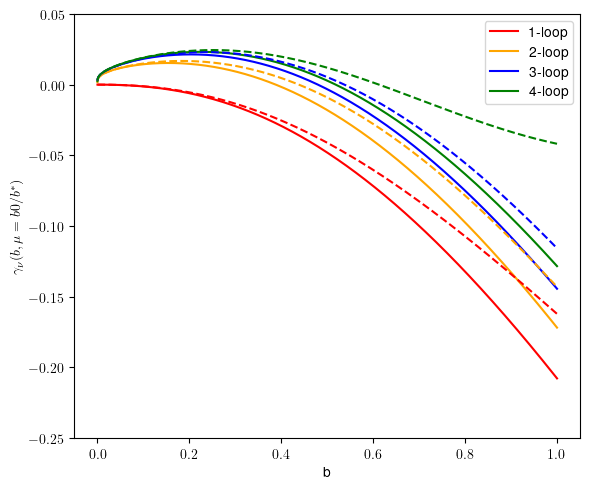

In [11]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),3,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

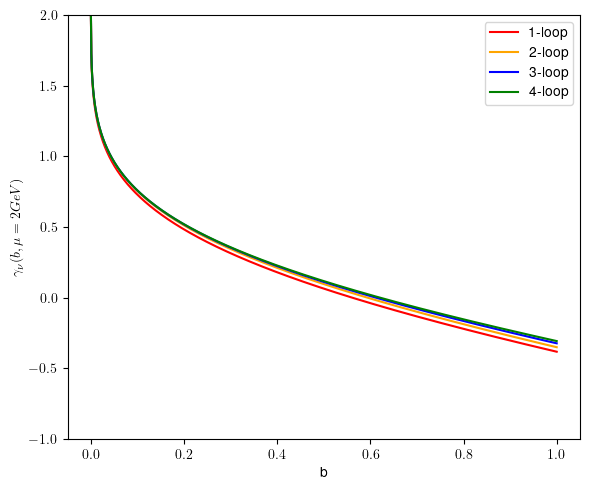

In [9]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=2GeV) $")
ax1.legend()

plt.ylim(-1,2)
plt.tight_layout()  
plt.show()

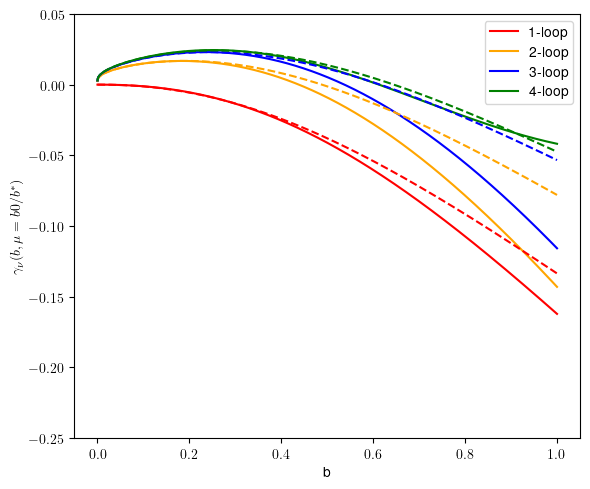

In [10]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

In [ ]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

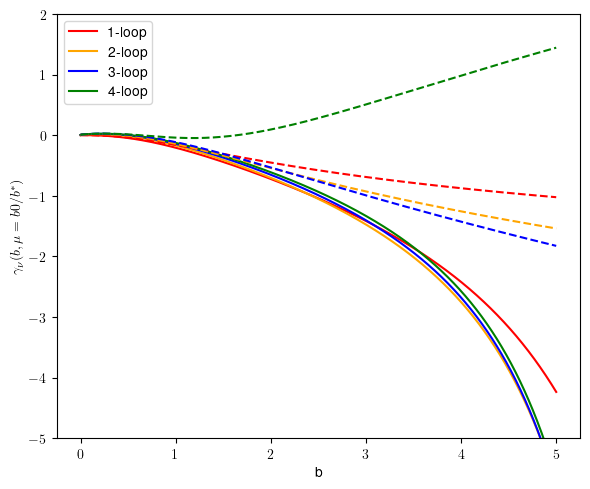

In [41]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),5,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-5,2)
plt.tight_layout()  
plt.show()

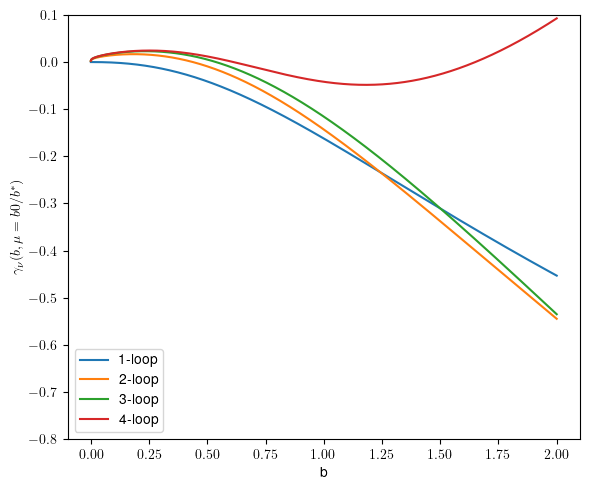

In [22]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),2,length)

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.8,0.1)
plt.tight_layout()  
plt.show()

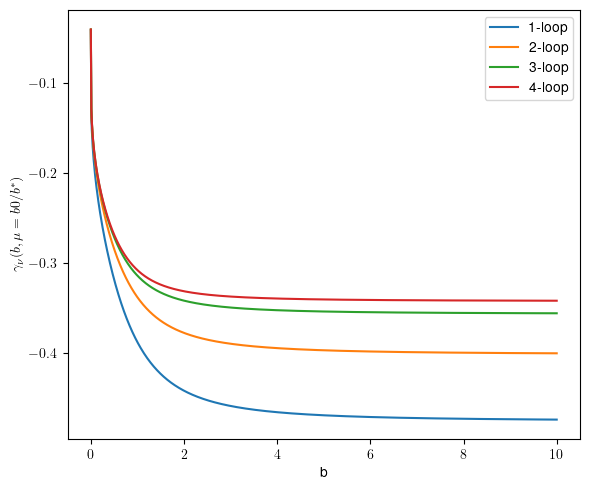

In [16]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-9),10,length)

α_list = np.zeros(length)

for index, bp in enumerate(b_list):
    α_list[index] = Main.alpha_s_func(μf=b0/(bp/(1+(bp/bmax)**2)**0.5), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    v_1[index] = Main.γν_raw(αs=α_list[index],  order=1, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.γν_raw(αs=α_list[index],  order=2, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.γν_raw(αs=α_list[index],  order=3, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.γν_raw(αs=α_list[index],  order=4, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop")
ax1.plot(b_list, v_2, label="2-loop")
ax1.plot(b_list, v_3, label="3-loop")
ax1.plot(b_list, v_4, label="4-loop")
ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.tight_layout()  
plt.show()

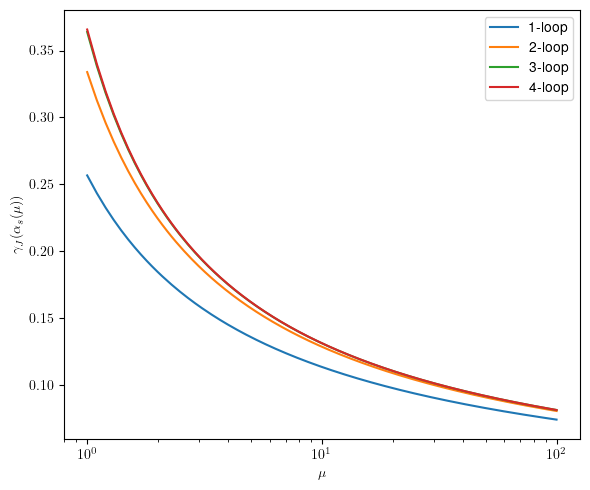

In [81]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(1,100,length)
α_list = np.zeros(length)

for index, mu in enumerate(mu_list):
    α_list[index] = Main.alpha_s_func(μf=float(mu), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, α in enumerate(α_list):    
    v_1[index] = Main.γB_tilde(αs=float(α),order=1,nf=5)
    v_2[index] = Main.γB_tilde(αs=float(α), order=2, nf=5)
    v_3[index] = Main.γB_tilde(αs=float(α), order=3, nf=5)
    v_4[index] = Main.γB_tilde(αs=float(α), order=4, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(mu_list, v_1, label="1-loop")
ax1.plot(mu_list, v_2, label="2-loop")
ax1.plot(mu_list, v_3, label="3-loop")
ax1.plot(mu_list, v_4, label="4-loop")
ax1.set_xlabel(r"\rm $\mu$")
ax1.set_ylabel( r"\rm $ \gamma_J(\alpha_s(\mu)) $")
ax1.set_xscale("log")
ax1.legend()

plt.tight_layout()  
plt.show()

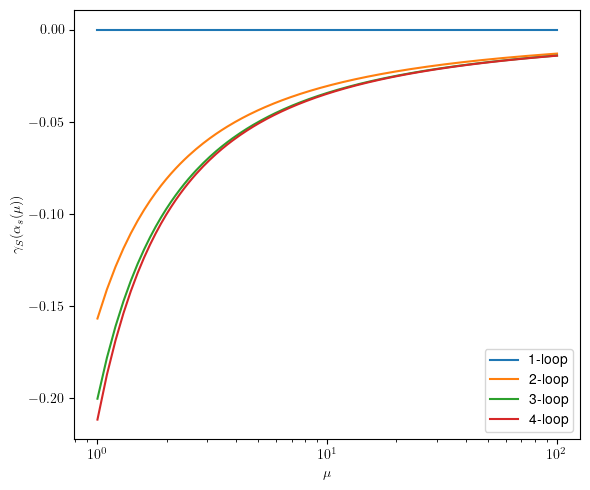

In [77]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(1,100,length)
α_list = np.zeros(length)

for index, mu in enumerate(mu_list):
    bstar = bp/(1+(bp/b0)**2)**0.5
    μ0 = b0/bstar
    α_list[index] = Main.alpha_s_func(μf=float(mu), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, α in enumerate(α_list):    
    v_1[index] = Main.γS_tilde(αs=float(α),order=1,nf=5)
    v_2[index] = Main.γS_tilde(αs=float(α), order=2, nf=5)
    v_3[index] = Main.γS_tilde(αs=float(α), order=3, nf=5)
    v_4[index] = Main.γS_tilde(αs=float(α), order=4, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(mu_list, v_1, label="1-loop")
ax1.plot(mu_list, v_2, label="2-loop")
ax1.plot(mu_list, v_3, label="3-loop")
ax1.plot(mu_list, v_4, label="4-loop")
ax1.set_xlabel(r"\rm $\mu$")
ax1.set_ylabel( r"\rm $ \gamma_S(\alpha_s(\mu)) $")
ax1.set_xscale("log")
ax1.legend()

plt.tight_layout()  
plt.show()

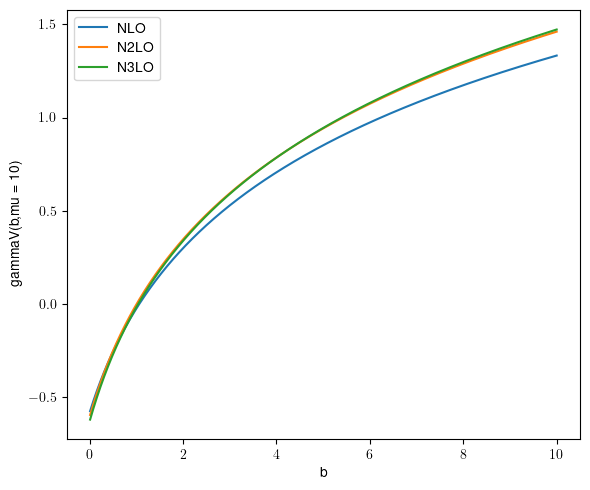

In [46]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(0.9,10,length)

for index, mu in enumerate(mu_list):
    v_1[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    v_2[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    v_3[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="NLO")
ax1.plot(b_list, v_2, label="N2LO")
ax1.plot(b_list, v_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('gammaV(b,mu = 10)')
ax1.legend()

plt.tight_layout()  
plt.show()

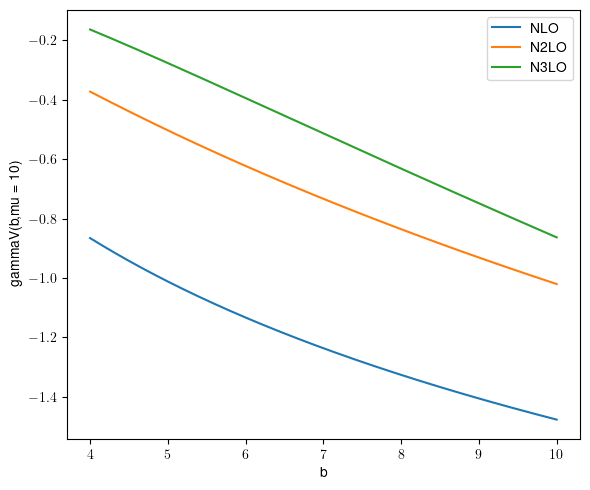

In [91]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(4,10,length)

for index, bp in enumerate(b_list):
    bstar = bp/(1+(bp/b0)**2)**0.5
    μ0 = b0/bstar
    α = Main.alpha_s_func(μf=μ0, μi=91.2, αs=0.118, order=3, nf=5)
    v_1[index] = (α/(4*3.14))*Main.γν1_final(np.log((bp*μ0/b0)**2),5)
    v_2[index] = (α/(4*3.14))**2*Main.γν2_final(np.log((bp*μ0/b0)**2),5)
    v_3[index] = (α/(4*3.14))**3*Main.γν3_final(np.log((bp*μ0/b0)**2),5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="NLO")
ax1.plot(b_list, v_2, label="N2LO")
ax1.plot(b_list, v_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('gammaV(b,mu = 10)')
ax1.legend()

plt.tight_layout()  
plt.show()